 
**Title:** `Renewable Energy Forecasting`   
 

**Description:** `This notebook reproduces all empirical results presented in the thesis.`    


# Abstract

This study addresses an important gap in renewable energy forecasting by systematically comparing different forecasting models for long-term prediction of monthly renewable energy consumption in the United States. While much of the existing literature focuses on short-term forecasting and high-frequency data, this research examines the reliability of classical statistical models, machine learning methods, and deep learning architectures when applied to lower-frequency monthly data that may exhibit structural changes over time.

An out-of-sample forecasting framework is developed to evaluate the performance of four representative models: **SARIMAX**, **Prophet**, **XGBoost**, and **Long Short-Term Memory (LSTM)** networks. The models are assessed using a recursive multi-step forecasting strategy with a **36-month forecasting horizon**. Forecast accuracy is evaluated using multiple performance metrics, including **Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), Symmetric Mean Absolute Percentage Error (SMAPE), and the coefficient of determination (R²)**.

The empirical results show that the **LSTM model consistently delivers the highest forecasting accuracy across all evaluation metrics**, maintaining relatively stable performance over the entire forecasting horizon. Statistical validation using the **Diebold–Mariano test** confirms that the predictive differences between LSTM and classical statistical models are statistically significant. While traditional models such as SARIMAX and Prophet produce smoother forecast trajectories and offer greater interpretability, their overall predictive accuracy is lower than that of the LSTM model. In contrast, the **XGBoost model demonstrates substantial instability and poor generalization performance in long-horizon forecasting scenarios**.

These findings challenge the common assumption that model complexity does not necessarily improve forecasting performance. The results suggest that **deep learning models can provide meaningful advantages even when applied to moderately sized monthly datasets**, provided that appropriate model design and regularization techniques are used.

Overall, the study highlights that **forecasting model performance is strongly context-dependent**, and the choice of model should align with the objectives of the forecasting task. While deep learning models may be preferable for maximizing predictive accuracy, classical statistical approaches remain valuable when interpretability and uncertainty estimation are critical.

**Keywords:** Renewable energy forecasting, Long-horizon forecasting, Time-series analysis, Deep learning, LSTM, SARIMAX, Machine learning, Structural breaks, Multi-step forecasting, Bias–variance trade-off.

### Library Installation
This cell installs all required Python libraries for data processing, visualization, and time-series analysis. It ensures that the computational environment contains the necessary dependencies for reproducibility.

In [ ]:
# Install all required libraries
!pip install pandas numpy matplotlib seaborn statsmodels

### Import Required Libraries
This section imports all core libraries used for exploratory data analysis, including data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and time-series diagnostics (statsmodels).

In [1]:
# Core libraries
import os
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from pandas.api.types import is_numeric_dtype

### EDA and Data Cleaning Pipeline Initialization
This cell defines the structured pipeline used for loading, cleaning, and preparing the dataset. It ensures consistent preprocessing before performing exploratory analysis.

In [2]:
# ============================
# EDA + Data Cleaning Pipeline (uses datasets/... paths)
# ============================


# -----------------------------
# Load datasets (paths updated to your 'datasets/' folder)
# -----------------------------
GLOBAL_PATH = 'datasets/global_energy_consumption.csv'
US_PATH = 'datasets/dataset.csv'

df_global = pd.read_csv(GLOBAL_PATH)
df_us = pd.read_csv(US_PATH)

print("GLOBAL dataset shape:", df_global.shape)
print("US dataset shape:", df_us.shape)

print("\nGLOBAL dataset info:")
print(df_global.info())

print("\nUS dataset info:")
print(df_us.info())

print("\nGLOBAL head:\n", df_global.head())
print("\nUS head:\n", df_us.head())

GLOBAL dataset shape: (10000, 10)
US dataset shape: (3065, 17)

GLOBAL dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          10000 non-null  object 
 1   Year                             10000 non-null  int64  
 2   Total Energy Consumption (TWh)   10000 non-null  float64
 3   Per Capita Energy Use (kWh)      10000 non-null  float64
 4   Renewable Energy Share (%)       10000 non-null  float64
 5   Fossil Fuel Dependency (%)       10000 non-null  float64
 6   Industrial Energy Use (%)        10000 non-null  float64
 7   Household Energy Use (%)         10000 non-null  float64
 8   Carbon Emissions (Million Tons)  10000 non-null  float64
 9   Energy Price Index (USD/kWh)     10000 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 781.4+ KB

In [3]:
# ============================
# EDA + Data Cleaning Pipeline (uses datasets/... paths)
# ============================

# -----------------------------
# 1. Load datasets (paths updated to your 'datasets/' folder)
# -----------------------------
GLOBAL_PATH = 'datasets/global_energy_consumption.csv'
US_PATH = 'datasets/dataset.csv'

df_global = pd.read_csv(GLOBAL_PATH)
df_us = pd.read_csv(US_PATH)

print("GLOBAL dataset shape:", df_global.shape)
print("US dataset shape:", df_us.shape)

print("\nGLOBAL dataset info:")
print(df_global.info())

print("\nUS dataset info:")
print(df_us.info())

print("\nGLOBAL head:\n", df_global.head())
print("\nUS head:\n", df_us.head())

GLOBAL dataset shape: (10000, 10)
US dataset shape: (3065, 17)

GLOBAL dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          10000 non-null  object 
 1   Year                             10000 non-null  int64  
 2   Total Energy Consumption (TWh)   10000 non-null  float64
 3   Per Capita Energy Use (kWh)      10000 non-null  float64
 4   Renewable Energy Share (%)       10000 non-null  float64
 5   Fossil Fuel Dependency (%)       10000 non-null  float64
 6   Industrial Energy Use (%)        10000 non-null  float64
 7   Household Energy Use (%)         10000 non-null  float64
 8   Carbon Emissions (Million Tons)  10000 non-null  float64
 9   Energy Price Index (USD/kWh)     10000 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 781.4+ KB

### Missing Value Analysis
This section evaluates the presence of missing values within the dataset to ensure data completeness and identify potential preprocessing requirements.

In [4]:
# -----------------------------
# 2. Missing value analysis
# -----------------------------
print("\nMissing values in GLOBAL dataset:\n", df_global.isna().sum())
print("\nMissing values in US dataset:\n", df_us.isna().sum())


Missing values in GLOBAL dataset:
 Country                            0
Year                               0
Total Energy Consumption (TWh)     0
Per Capita Energy Use (kWh)        0
Renewable Energy Share (%)         0
Fossil Fuel Dependency (%)         0
Industrial Energy Use (%)          0
Household Energy Use (%)           0
Carbon Emissions (Million Tons)    0
Energy Price Index (USD/kWh)       0
dtype: int64

Missing values in US dataset:
 Year                                  0
Month                                 0
Sector                                0
Hydroelectric Power                   0
Geothermal Energy                     0
Solar Energy                          0
Wind Energy                           0
Wood Energy                           0
Waste Energy                          0
Fuel Ethanol, Excluding Denaturant    0
Biomass Losses and Co-products        0
Biomass Energy                        0
Total Renewable Energy                0
Renewable Diesel Fuel        

### Date Conversion and Formatting
The date column is converted into a proper datetime format to enable time-series indexing, chronological sorting, and temporal aggregation.

In [5]:
# -----------------------------
# Convert Date column in US to datetime
# -----------------------------
date_col_candidates = [c for c in df_us.columns if "date" in c.lower() or "month" in c.lower()]
date_col = date_col_candidates[0] if date_col_candidates else df_us.columns[0]

df_us[date_col] = pd.to_datetime(df_us[date_col], errors='coerce')
df_us = df_us.set_index(date_col).sort_index()

print("\nDate index range:", df_us.index.min(), "to", df_us.index.max())


Date index range: 1970-01-01 00:00:00.000000001 to 1970-01-01 00:00:00.000000012


### Identification of Renewable Energy Variables
This step detects and selects relevant renewable energy consumption columns used for aggregation and forecasting.

In [6]:
# -----------------------------
# Detect renewable columns
# -----------------------------
renewable_keywords = ['solar','wind','hydro','biomass','geothermal','renew','bio']
renew_cols = [c for c in df_us.columns if any(k in c.lower() for k in renewable_keywords)]

print("\nDetected renewable columns:", renew_cols)

# Identify total renewable column
total_candidates = [c for c in df_us.columns if 'total' in c.lower() and 'renew' in c.lower()]
total_col = total_candidates[0] if total_candidates else (renew_cols[0] if renew_cols else df_us.columns[0])

print("Using TOTAL renewable column:", total_col)



Detected renewable columns: ['Hydroelectric Power', 'Geothermal Energy', 'Solar Energy', 'Wind Energy', 'Biomass Losses and Co-products', 'Biomass Energy', 'Total Renewable Energy', 'Renewable Diesel Fuel', 'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel']
Using TOTAL renewable column: Total Renewable Energy


### Identification of Renewable Energy Variables
This step detects and selects relevant renewable energy consumption columns used for aggregation and forecasting.

In [14]:
# ----------------------------
# Paths - update if needed
# ----------------------------
US_PATH = "datasets/dataset.csv"
GLOBAL_PATH = "datasets/global_energy_consumption.csv"
OUT_DIR = "datasets/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "figs"), exist_ok=True)

# ----------------------------
# Utility: save and show fig
# ----------------------------
def save_show(fig, fname, dpi=150, show=True):
    path = os.path.join(OUT_DIR, "figs", fname)
    fig.savefig(path, bbox_inches='tight', dpi=dpi)
    if show:
        plt.show()
    plt.close(fig)
    print("Saved:", path)

df_us_raw = pd.read_csv(US_PATH)
df_global = pd.read_csv(GLOBAL_PATH)

print("US raw shape:", df_us_raw.shape)
print("US columns:", df_us_raw.columns.tolist())
print("Global shape:", df_global.shape)
print("Global columns:", df_global.columns.tolist())

# ----------------------------
# Build correct datetime (Year + Month)
# ----------------------------
# Expect integer Year and Month (1-12)
if not {'Year', 'Month'}.issubset(df_us_raw.columns):
    raise ValueError("US dataset must contain 'Year' and 'Month' columns.")

df_us = df_us_raw.copy()
# If Month is numeric strings like '1' or '01', this will work
df_us['Date'] = pd.to_datetime(df_us['Year'].astype(int).astype(str) + '-' +
                              df_us['Month'].astype(int).astype(str).str.zfill(2) + '-01',
                              format='%Y-%m-%d', errors='coerce')
print("Parsed dates: min ->", df_us['Date'].min(), ", max ->", df_us['Date'].max())
if df_us['Date'].isna().any():
    print("Warning: some Month/Year combinations failed to parse. Examples:")
    print(df_us.loc[df_us['Date'].isna(), ['Year', 'Month']].head())

US raw shape: (3065, 17)
US columns: ['Year', 'Month', 'Sector', 'Hydroelectric Power', 'Geothermal Energy', 'Solar Energy', 'Wind Energy', 'Wood Energy', 'Waste Energy', 'Fuel Ethanol, Excluding Denaturant', 'Biomass Losses and Co-products', 'Biomass Energy', 'Total Renewable Energy', 'Renewable Diesel Fuel', 'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel']
Global shape: (10000, 10)
Global columns: ['Country', 'Year', 'Total Energy Consumption (TWh)', 'Per Capita Energy Use (kWh)', 'Renewable Energy Share (%)', 'Fossil Fuel Dependency (%)', 'Industrial Energy Use (%)', 'Household Energy Use (%)', 'Carbon Emissions (Million Tons)', 'Energy Price Index (USD/kWh)']
Parsed dates: min -> 1973-01-01 00:00:00 , max -> 2024-01-01 00:00:00


### Monthly Aggregation Across Sectors
Renewable energy values are aggregated across sectors to construct the total monthly renewable energy consumption time series used for forecasting.

In [15]:
# ----------------------------
# Aggregate across Sectors (sum numeric energy columns per month)
# ----------------------------
# Identify numeric columns to sum (exclude Year, Month)
numeric_cols = [c for c in df_us.columns if is_numeric_dtype(df_us[c]) and c not in ['Year','Month']]
if not numeric_cols:
    raise ValueError("No numeric columns found for aggregation.")

df_us['MonthPeriod'] = df_us['Date'].dt.to_period('M')
df_us_agg = df_us.groupby('MonthPeriod')[numeric_cols].sum().sort_index()
# convert PeriodIndex -> DatetimeIndex at month start (MS)
df_us_agg.index = df_us_agg.index.to_timestamp()
print("Aggregated monthly shape:", df_us_agg.shape, "from", df_us_agg.index.min(), "to", df_us_agg.index.max())

# Save cleaned aggregated CSV
clean_us_path = os.path.join("datasets", "clean_us_agg.csv")
df_us_agg.to_csv(clean_us_path)
print("Saved cleaned aggregated US CSV:", clean_us_path)

# Clean global quick cleanup (drop duplicates, remove negative numeric values)
clean_global = df_global.drop_duplicates().copy()
numcols_global = clean_global.select_dtypes(include=[np.number]).columns
clean_global[numcols_global] = clean_global[numcols_global].applymap(lambda x: np.nan if isinstance(x,(int,float)) and x < 0 else x)
clean_global_path = os.path.join("datasets", "clean_global.csv")
clean_global.to_csv(clean_global_path, index=False)
print("Saved cleaned global CSV:", clean_global_path)

Aggregated monthly shape: (613, 14) from 1973-01-01 00:00:00 to 2024-01-01 00:00:00
Saved cleaned aggregated US CSV: datasets\clean_us_agg.csv
Saved cleaned global CSV: datasets\clean_global.csv


C:\Users\Kamal_FOM\AppData\Local\Temp\ipykernel_18364\330726418.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  clean_global[numcols_global] = clean_global[numcols_global].applymap(lambda x: np.nan if isinstance(x,(int,float)) and x < 0 else x)


In [16]:

# ----------------------------
# Detect renewable/source columns and total column
# ----------------------------
renewable_keywords = ['solar','wind','hydro','biomass','geothermal','wood','waste','renew','bio']
renew_cols = [c for c in df_us_agg.columns if any(k in c.lower() for k in renewable_keywords)]
# preferred total col name
total_col_candidates = [c for c in df_us_agg.columns if 'total' in c.lower() and 'renew' in c.lower()]
if 'Total Renewable Energy' in df_us_agg.columns:
    total_col = 'Total Renewable Energy'
elif total_col_candidates:
    total_col = total_col_candidates[0]
elif renew_cols:
    total_col = renew_cols[0]
else:
    total_col = df_us_agg.columns[0]

print("Detected renewables:", renew_cols)
print("Total column used:", total_col)

Detected renewables: ['Hydroelectric Power', 'Geothermal Energy', 'Solar Energy', 'Wind Energy', 'Wood Energy', 'Waste Energy', 'Biomass Losses and Co-products', 'Biomass Energy', 'Total Renewable Energy', 'Renewable Diesel Fuel', 'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel']
Total column used: Total Renewable Energy


### Historical Trend Visualization (1973–2024)
This plot visualizes the long-term evolution of renewable energy consumption, highlighting structural growth phases and potential regime changes.

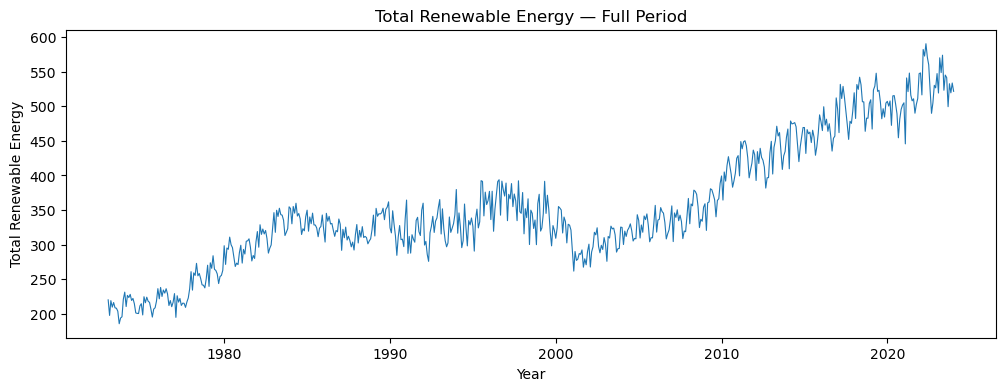

Saved: datasets/outputs\figs\trend_total_full.png


In [17]:
# ----------------------------
# Basic trend plot (long)
# ----------------------------
fig = plt.figure(figsize=(12,4))
plt.plot(df_us_agg.index, df_us_agg[total_col], linewidth=0.8)
plt.title("Total Renewable Energy — Full Period")
plt.xlabel("Year")
plt.ylabel(total_col)
save_show(fig, "trend_total_full.png")

### STL Decomposition
Seasonal-Trend decomposition using Loess (STL) is applied to separate the series into trend, seasonal, and residual components, enabling structural interpretation.

C:\Users\Kamal_FOM\AppData\Local\Temp\ipykernel_18364\16486981.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = df_us_agg[total_col].asfreq('MS').interpolate(limit=6).fillna(method='ffill').fillna(method='bfill')


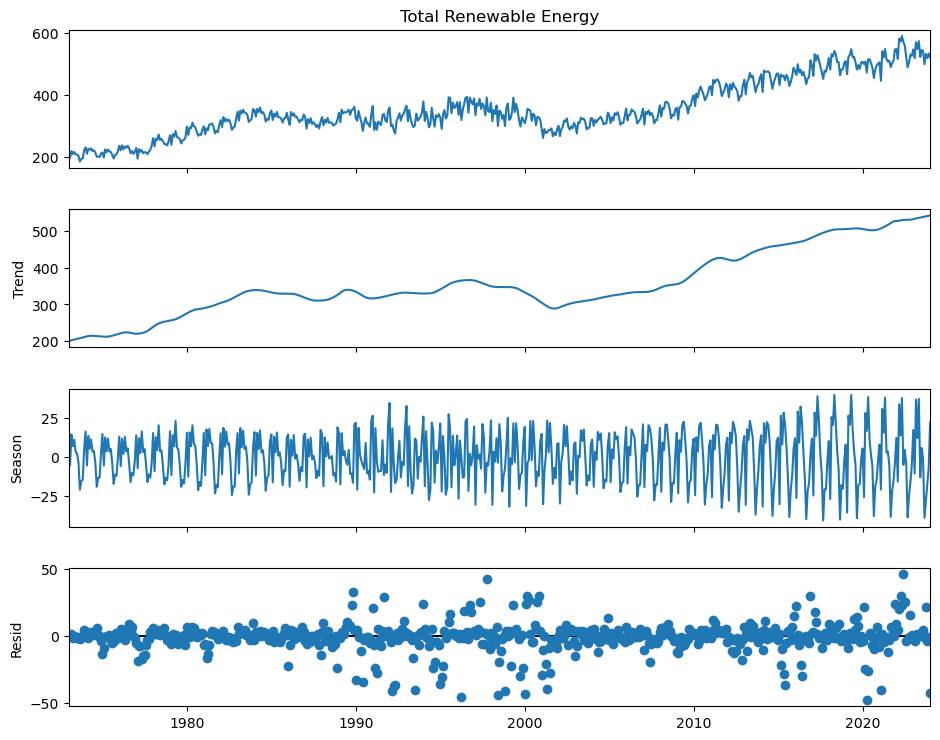

Saved: datasets/outputs\figs\stl_decomposition.png


In [18]:
# ----------------------------
# STL decomposition (prefer over classical) - if enough data
# ----------------------------
if len(df_us_agg) >= 24:
    series = df_us_agg[total_col].asfreq('MS').interpolate(limit=6).fillna(method='ffill').fillna(method='bfill')
    stl = STL(series, period=12, robust=True)
    res = stl.fit()
    # plot STL parts (clean)
    fig = res.plot()
    fig.set_size_inches(10,8)
    save_show(fig, "stl_decomposition.png")
else:
    print("Not enough months for STL decomposition (need >=24). Skipping STL.")

### Monthly Seasonality Distribution
A monthly boxplot is generated to examine seasonal variation patterns and detect systematic differences across calendar months.

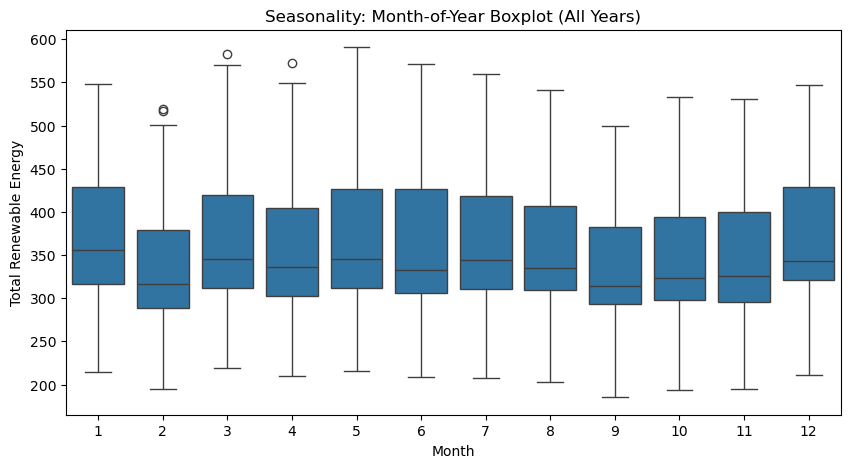

Saved: datasets/outputs\figs\seasonality_boxplot.png


In [19]:
# ----------------------------
# Monthly seasonality boxplot (clean, best for paper)
# ----------------------------
df_us_agg_box = df_us_agg.copy()
df_us_agg_box['month'] = df_us_agg_box.index.month
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='month', y=total_col, data=df_us_agg_box.reset_index(), ax=ax)
ax.set_title("Seasonality: Month-of-Year Boxplot (All Years)")
ax.set_xlabel("Month")
ax.set_ylabel(total_col)
save_show(fig, "seasonality_boxplot.png")

### Consolidated Clean EDA Script
This section consolidates all preprocessing and exploratory steps into a structured workflow to ensure clarity and reproducibility.

In [20]:
# Full clean EDA script for your datasets


warnings.filterwarnings("ignore")
%matplotlib inline

# ----------------------------
# Paths - update if needed
# ----------------------------
US_PATH = "datasets/dataset.csv"
GLOBAL_PATH = "datasets/global_energy_consumption.csv"
OUT_DIR = "datasets/outputs"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "figs"), exist_ok=True)

# ----------------------------
# Utility: save and show fig
# ----------------------------
def save_show(fig, fname, dpi=150, show=True):
    path = os.path.join(OUT_DIR, "figs", fname)
    fig.savefig(path, bbox_inches='tight', dpi=dpi)
    if show:
        plt.show()
    plt.close(fig)
    print("Saved:", path)

# ----------------------------
#  Load & quick inspect
# ----------------------------
df_us_raw = pd.read_csv(US_PATH)
df_global = pd.read_csv(GLOBAL_PATH)

print("US raw shape:", df_us_raw.shape)
print("US columns:", df_us_raw.columns.tolist())
print("Global shape:", df_global.shape)
print("Global columns:", df_global.columns.tolist())

US raw shape: (3065, 17)
US columns: ['Year', 'Month', 'Sector', 'Hydroelectric Power', 'Geothermal Energy', 'Solar Energy', 'Wind Energy', 'Wood Energy', 'Waste Energy', 'Fuel Ethanol, Excluding Denaturant', 'Biomass Losses and Co-products', 'Biomass Energy', 'Total Renewable Energy', 'Renewable Diesel Fuel', 'Other Biofuels', 'Conventional Hydroelectric Power', 'Biodiesel']
Global shape: (10000, 10)
Global columns: ['Country', 'Year', 'Total Energy Consumption (TWh)', 'Per Capita Energy Use (kWh)', 'Renewable Energy Share (%)', 'Fossil Fuel Dependency (%)', 'Industrial Energy Use (%)', 'Household Energy Use (%)', 'Carbon Emissions (Million Tons)', 'Energy Price Index (USD/kWh)']


### Seasonal Subseries Analysis
This visualization displays seasonal patterns across years, enabling comparison of monthly behavior and long-term seasonal stability.

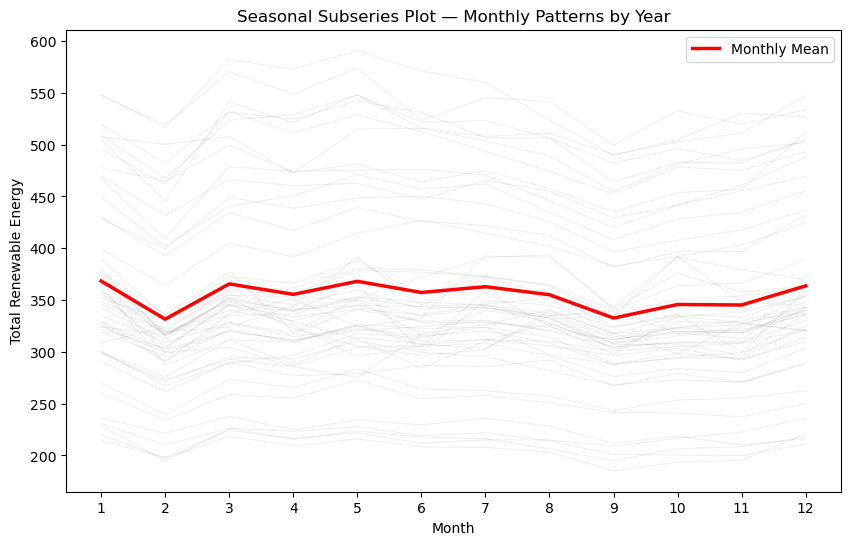

Saved: datasets/outputs\figs\seasonal_subseries.png


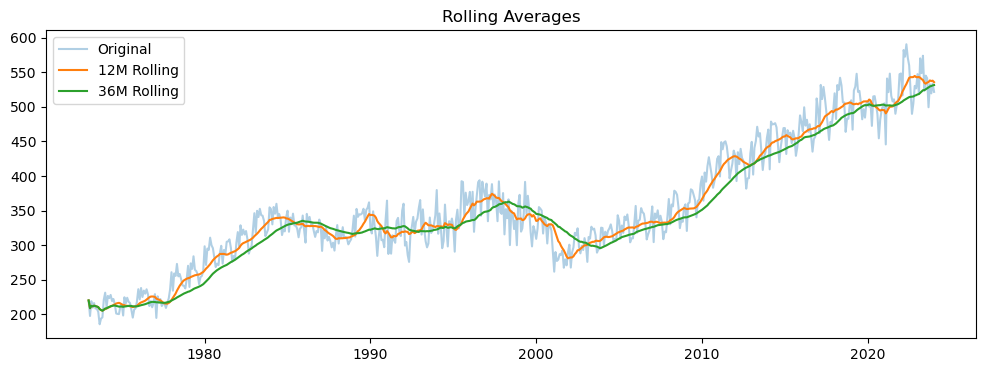

Saved: datasets/outputs\figs\rolling_averages.png


In [21]:
# ----------------------------
# Seasonal subseries plot (all years faint, mean bold)
# ----------------------------
fig = plt.figure(figsize=(10,6))
# faint lines per year
for year, g in df_us_agg.groupby(df_us_agg.index.year):
    plt.plot(g.index.month, g[total_col], color='gray', alpha=0.12, linewidth=0.8)
# mean per month
monthly_mean = df_us_agg.groupby(df_us_agg.index.month)[total_col].mean()
plt.plot(range(1,13), monthly_mean.values, color='red', linewidth=2.5, label='Monthly Mean')
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel(total_col)
plt.title("Seasonal Subseries Plot — Monthly Patterns by Year")
plt.legend()
save_show(fig, "seasonal_subseries.png")

# ----------------------------
# Rolling averages (12 & 36 months)
# ----------------------------
df_us_agg['rolling_12m'] = df_us_agg[total_col].rolling(window=12, min_periods=1).mean()
df_us_agg['rolling_36m'] = df_us_agg[total_col].rolling(window=36, min_periods=1).mean()
fig = plt.figure(figsize=(12,4))
plt.plot(df_us_agg.index, df_us_agg[total_col], alpha=0.35, label='Original')
plt.plot(df_us_agg.index, df_us_agg['rolling_12m'], linewidth=1.5, label='12M Rolling')
plt.plot(df_us_agg.index, df_us_agg['rolling_36m'], linewidth=1.5, label='36M Rolling')
plt.legend(); plt.title("Rolling Averages")
save_show(fig, "rolling_averages.png")

### Correlation Analysis
A correlation heatmap is constructed to examine relationships among renewable energy components and identify co-movement patterns.

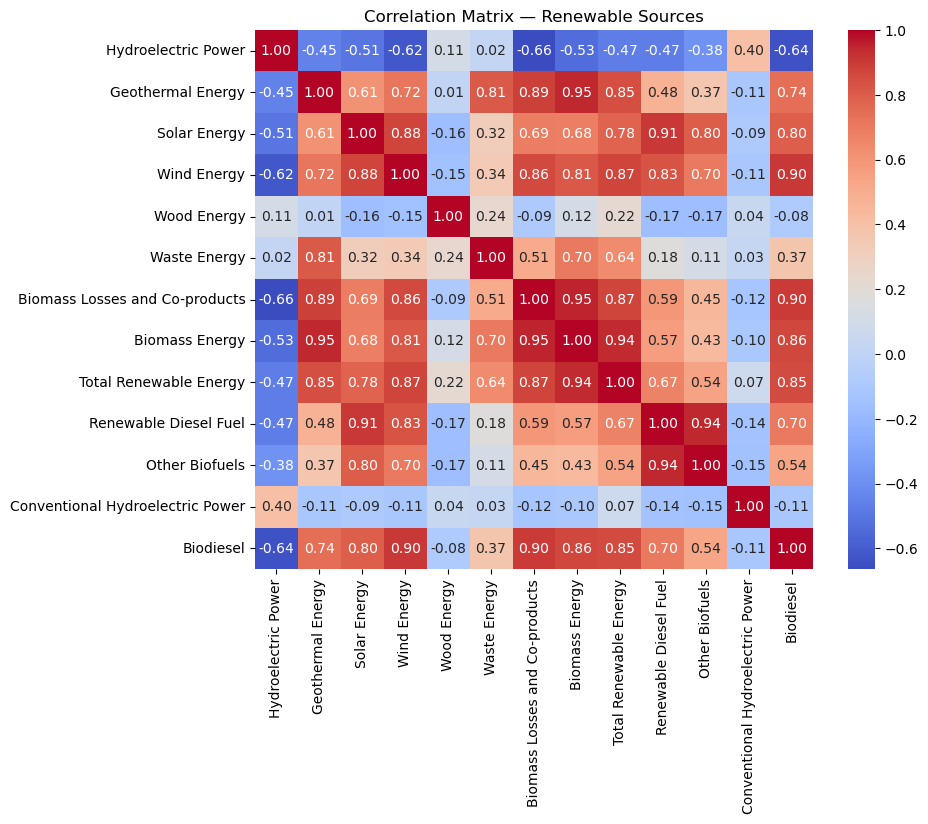

Saved: datasets/outputs\figs\correlation_heatmap.png


In [22]:
# ----------------------------
#  Correlation heatmap among renewables
# ----------------------------
if len(renew_cols) >= 2:
    corr = df_us_agg[renew_cols].corr()
    fig = plt.figure(figsize=(9,7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=False)
    plt.title("Correlation Matrix — Renewable Sources")
    save_show(fig, "correlation_heatmap.png")
else:
    print("Not enough renewable columns for correlation heatmap.")





### Pairwise Relationship Exploration
Sample scatter plots are used to explore nonlinear relationships and dependencies between selected renewable energy variables.

In [23]:
# ----------------------------
#  Pairwise scatter (sample) - avoid huge plots
# ----------------------------
if len(renew_cols) >= 2:
    sample = df_us_agg[renew_cols].dropna().sample(min(500, len(df_us_agg)))
    g = sns.pairplot(sample)
    g.fig.suptitle("Pairwise Scatter (sample)", y=1.02)
    g.fig.savefig(os.path.join(OUT_DIR, "figs", "pairwise_scatter_sample.png"), bbox_inches='tight', dpi=150)
    plt.close(g.fig)
    print("Saved: pairwise_scatter_sample.png")
else:
    print("Not enough renew_cols for pairwise scatter.")

Saved: pairwise_scatter_sample.png


### Distribution and Outlier Analysis
Boxplots and distribution plots are generated to identify skewness, dispersion, and potential outliers within the dataset.

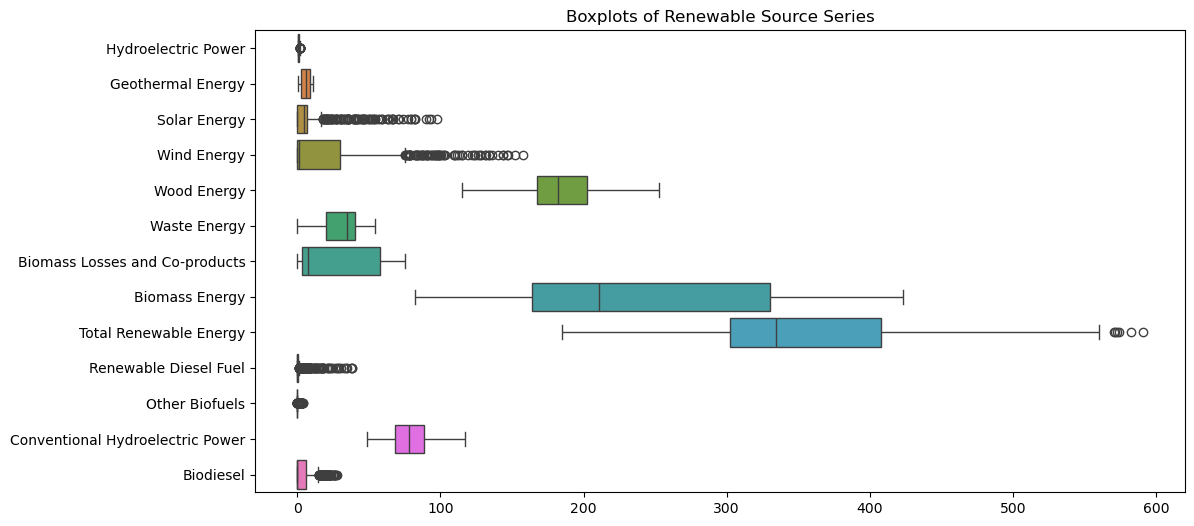

Saved: datasets/outputs\figs\boxplots_sources.png


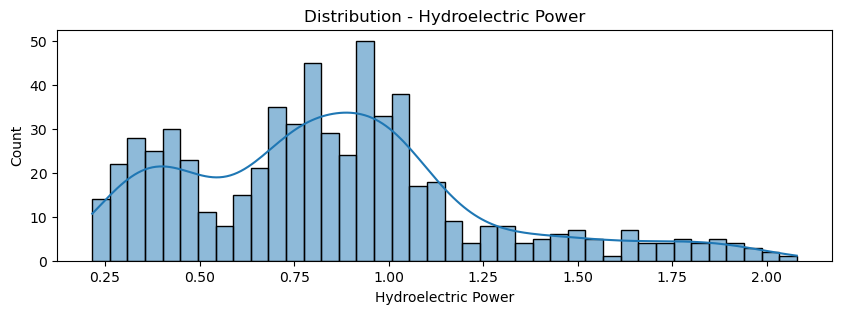

Saved: datasets/outputs\figs\dist_Hydroelectric_Power.png


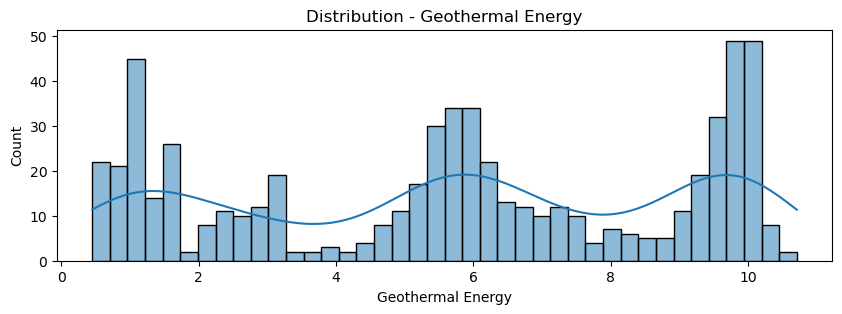

Saved: datasets/outputs\figs\dist_Geothermal_Energy.png


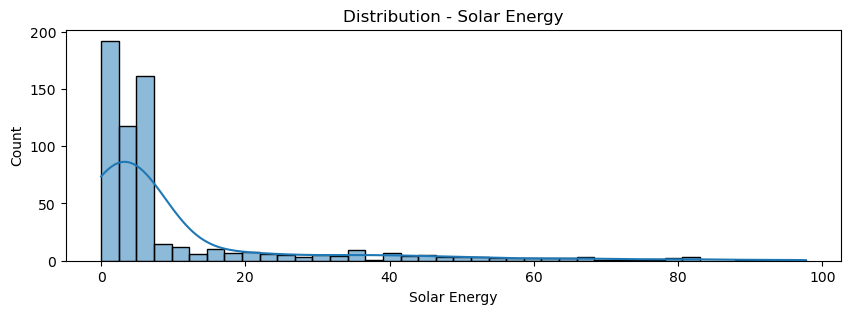

Saved: datasets/outputs\figs\dist_Solar_Energy.png


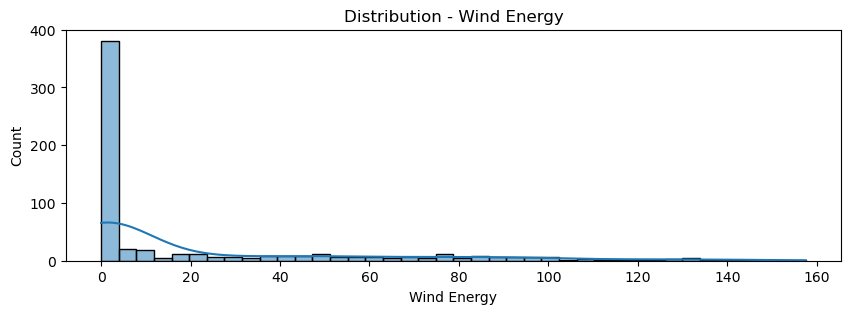

Saved: datasets/outputs\figs\dist_Wind_Energy.png


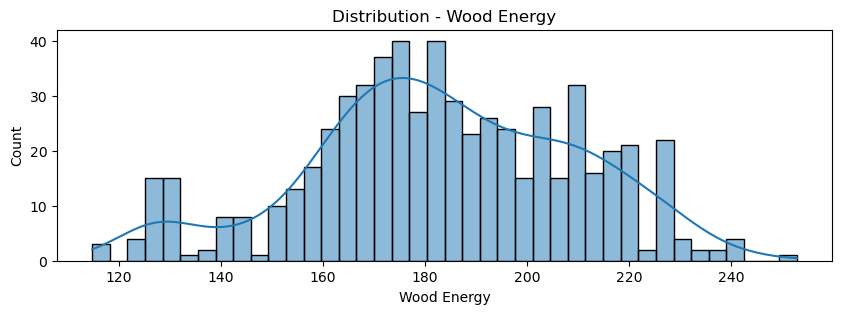

Saved: datasets/outputs\figs\dist_Wood_Energy.png


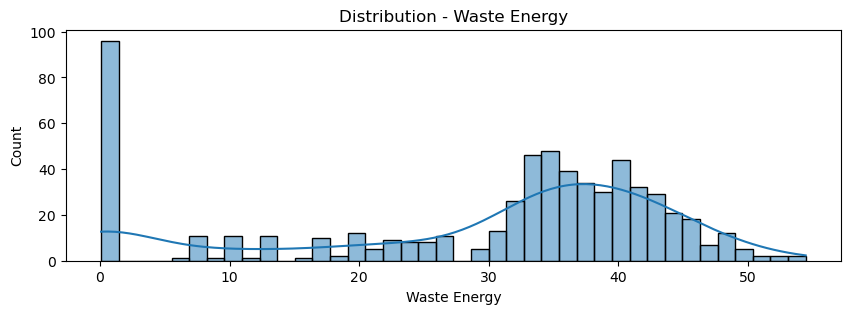

Saved: datasets/outputs\figs\dist_Waste_Energy.png


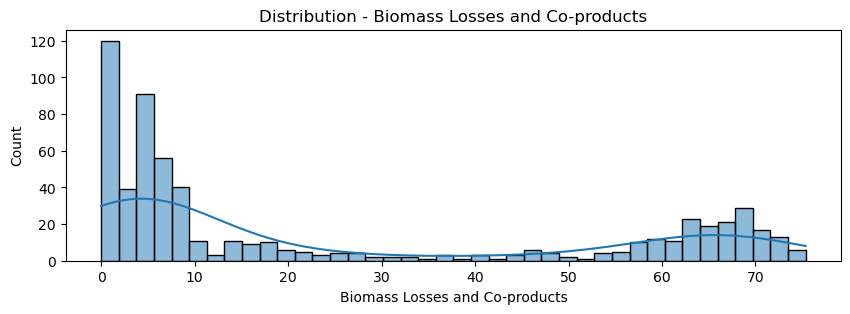

Saved: datasets/outputs\figs\dist_Biomass_Losses_and_Co-products.png


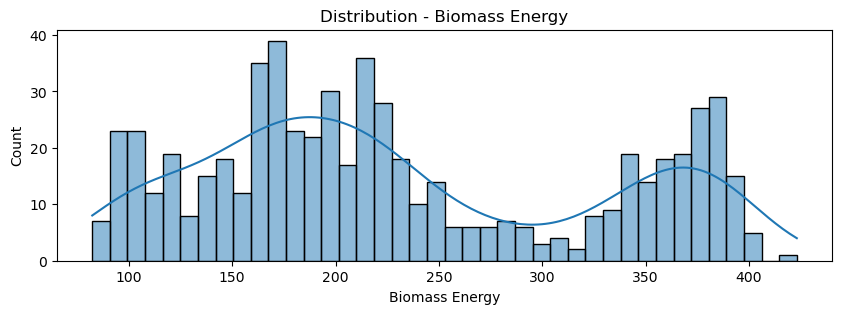

Saved: datasets/outputs\figs\dist_Biomass_Energy.png


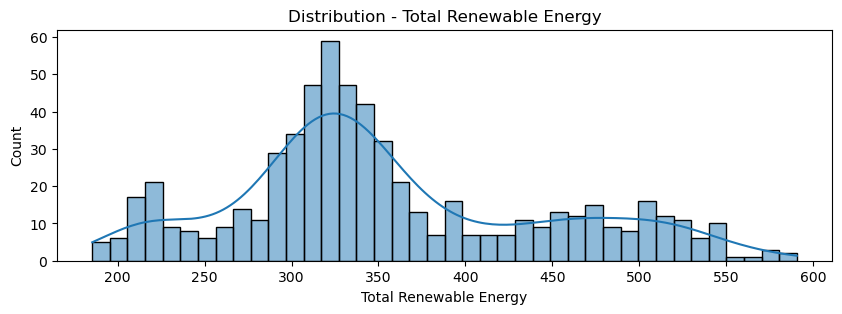

Saved: datasets/outputs\figs\dist_Total_Renewable_Energy.png


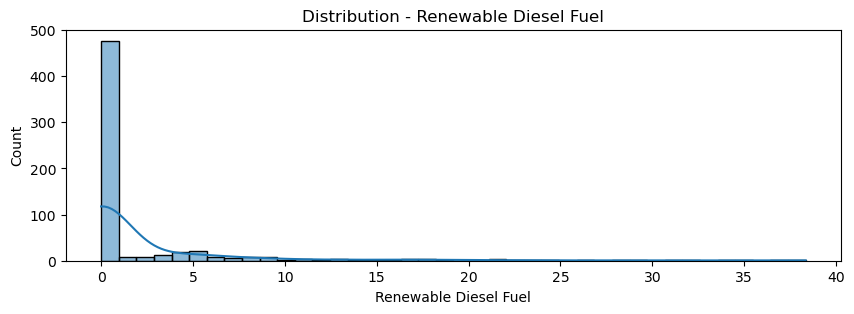

Saved: datasets/outputs\figs\dist_Renewable_Diesel_Fuel.png


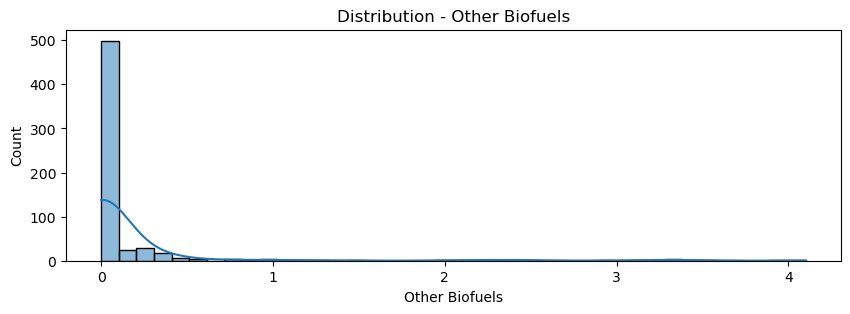

Saved: datasets/outputs\figs\dist_Other_Biofuels.png


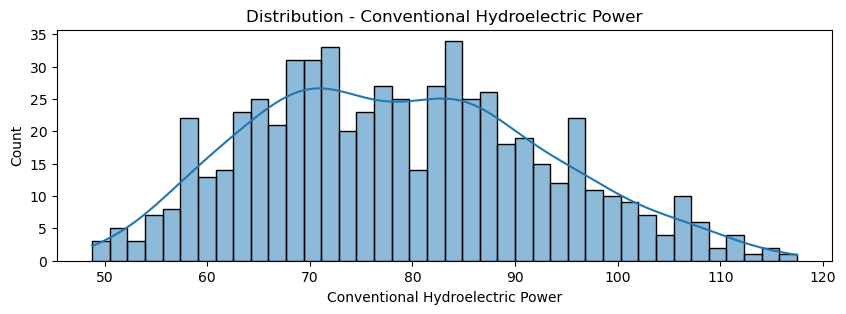

Saved: datasets/outputs\figs\dist_Conventional_Hydroelectric_Power.png


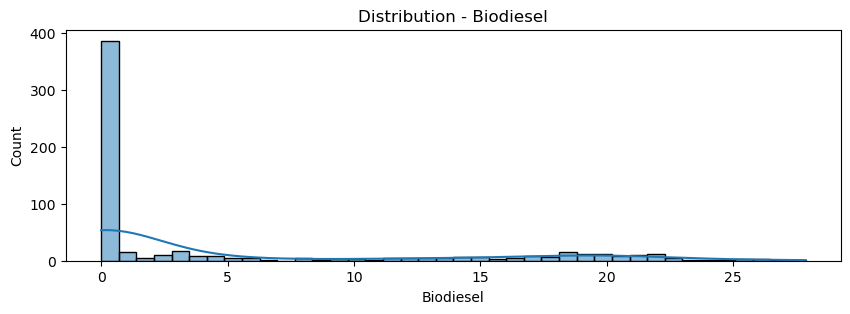

Saved: datasets/outputs\figs\dist_Biodiesel.png


In [24]:
# ----------------------------
#  Boxplots & distributions
# ----------------------------
if renew_cols:
    fig = plt.figure(figsize=(12,6))
    sns.boxplot(data=df_us_agg[renew_cols], orient='h')
    plt.title("Boxplots of Renewable Source Series")
    save_show(fig, "boxplots_sources.png")

    for c in renew_cols:
        fig = plt.figure(figsize=(10,3))
        sns.histplot(df_us_agg[c].dropna(), kde=True, bins=40)
        plt.title(f"Distribution - {c}")
        save_show(fig, f"dist_{c.replace(' ', '_')}.png")
else:
    print("No renew_cols detected for boxplots/distributions.")

### Sectoral Contribution Analysis
A stacked area chart visualizes sector-wise contributions to total renewable energy consumption over time.

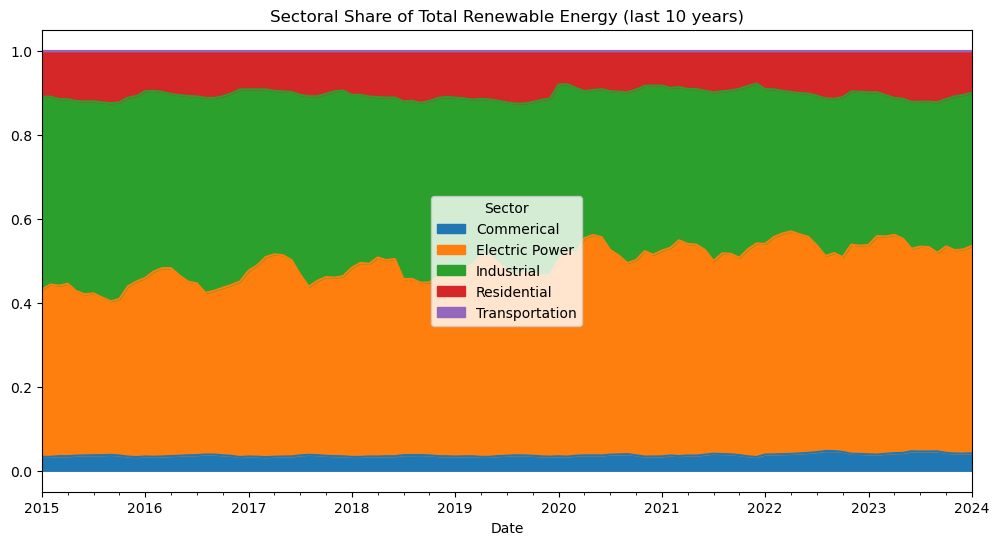

Saved: datasets/outputs\figs\sectoral_share_last10y.png


In [25]:
# ----------------------------
#  Sectoral breakdown (stacked area) - uses raw sector-level file
# ----------------------------
if 'Sector' in df_us.columns:
    raw = df_us_raw.copy()
    raw['Date'] = pd.to_datetime(raw['Year'].astype(int).astype(str) + '-' +
                                 raw['Month'].astype(int).astype(str).str.zfill(2) + '-01', errors='coerce')
    # use Total Renewable Energy if present in raw (value column)
    val_col = 'Total Renewable Energy' if 'Total Renewable Energy' in raw.columns else numeric_cols[0]
    pivot = raw.pivot_table(index='Date', columns='Sector', values=val_col, aggfunc='sum').fillna(0)
    if pivot.shape[1] > 0 and pivot.shape[0] > 0:
        pct = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        # plot last 10 years for clarity
        try:
            pct_recent = pct.last('10Y')
            fig = pct_recent.plot.area(figsize=(12,6)).figure
            plt.title("Sectoral Share of Total Renewable Energy (last 10 years)")
            save_show(fig, "sectoral_share_last10y.png")
        except Exception:
            # fallback plot full period
            fig = pct.plot.area(figsize=(12,6)).figure
            plt.title("Sectoral Share of Total Renewable Energy (full period)")
            save_show(fig, "sectoral_share_full.png")
    else:
        print("Pivot empty for sectoral breakdown.")
else:
    print("No 'Sector' column in raw; cannot create sectoral breakdown.")

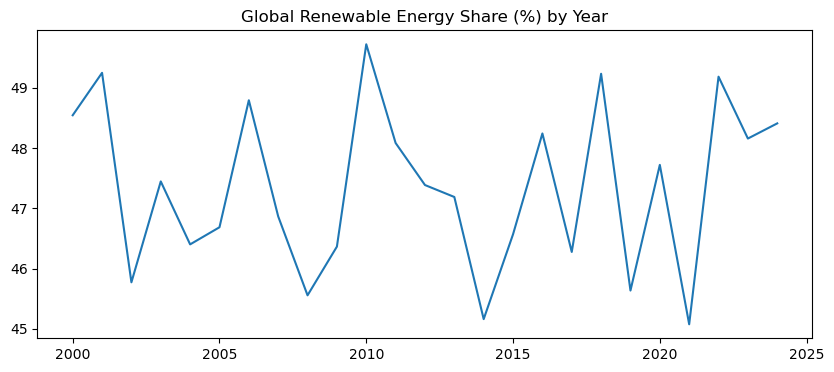

Saved: datasets/outputs\figs\global_renewable_share.png


In [26]:

# ----------------------------
#  Quick global overview (Renewable Energy Share % by year)
# ----------------------------
if 'Year' in clean_global.columns and 'Renewable Energy Share (%)' in clean_global.columns:
    g = clean_global.groupby('Year')['Renewable Energy Share (%)'].mean()
    fig = plt.figure(figsize=(10,4))
    plt.plot(g.index, g.values)
    plt.title("Global Renewable Energy Share (%) by Year")
    save_show(fig, "global_renewable_share.png")
else:
    print("Global dataset doesn't contain expected columns for global overview.")

### EDA Summary
This section summarizes key exploratory findings, including trend growth, seasonality presence, and structural dynamics observed in the dataset.

In [27]:
# ----------------------------
#  Final summary
# ----------------------------
print("\nEDA complete.")
print("Clean aggregated US CSV:", clean_us_path)
print("Cleaned global CSV:", clean_global_path)
print("Figures saved to:", os.path.join(OUT_DIR, "figs"))


EDA complete.
Clean aggregated US CSV: datasets\clean_us_agg.csv
Cleaned global CSV: datasets\clean_global.csv
Figures saved to: datasets/outputs\figs


### Stationarity Testing (ADF Test)
The Augmented Dickey–Fuller test is applied to evaluate whether the time series is stationary or requires differencing prior to model estimation.

In [28]:
# ==========================================
#  STATIONARITY TESTING (Corrected)
# ==========================================

series = df_us_agg[total_col].dropna()

print("===== Augmented Dickey-Fuller Test =====")
adf_result = adfuller(series)

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

if adf_result[1] < 0.05:
    print("Conclusion: Series is stationary.")
else:
    print("Conclusion: Series is non-stationary.")

===== Augmented Dickey-Fuller Test =====
ADF Statistic: -0.3476
p-value: 0.9185
Conclusion: Series is non-stationary.


### First-Order Differencing
The series is differenced to remove trend components and achieve stationarity, as required for ARIMA-based modeling.

In [29]:
diff_series = series.diff().dropna()

print("===== ADF Test on Differenced Series =====")
adf_diff = adfuller(diff_series)

print(f"ADF Statistic: {adf_diff[0]:.4f}")
print(f"p-value: {adf_diff[1]:.4f}")

===== ADF Test on Differenced Series =====
ADF Statistic: -6.6597
p-value: 0.0000


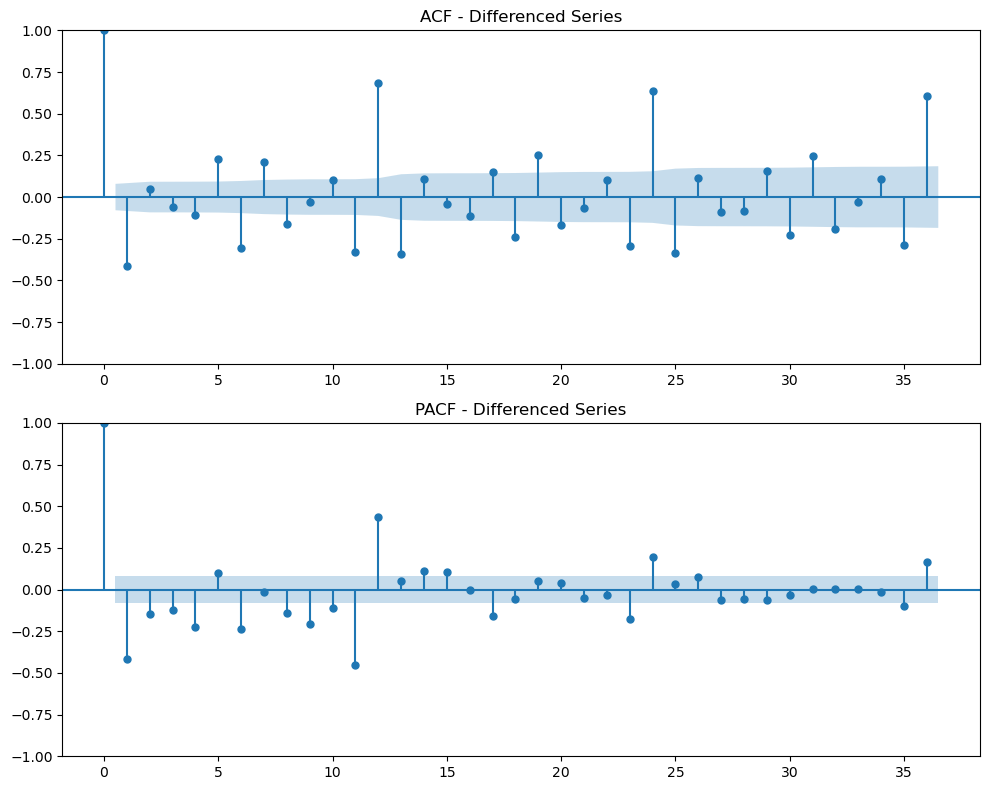

In [30]:


fig, ax = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(diff_series, lags=36, ax=ax[0])
ax[0].set_title("ACF - Differenced Series")

plot_pacf(diff_series, lags=36, ax=ax[1])
ax[1].set_title("PACF - Differenced Series")

plt.tight_layout()
plt.show()